In [133]:
import pandas as pd
pd.set_option('display.max_columns', None)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr, ttest_ind

In [134]:
df = pd.read_csv("../data/processed data/merged_data_V2.csv")
df.head()

,SWEAT index,K index,Totals totals index,Date,TH,Environmental Stability,Moisture Indices,Convective Potential,Temperature Pressure,Moisture Temperature Profiles
0,91.2,-1.4,24.7,1981-01-01,0,25.8,22.8,0.0,5636,993.98
1,75.7,1.6,30.3,1981-01-02,0,21.5,20.4,0.0,5592,956.13
2,64.0,2.8,37.5,1981-01-03,0,1.9,19.7,-259.7,5636,862.29
3,128.3,17.5,41.6,1981-01-04,0,13.8,23.8,0.0,5581,978.71
4,194.2,23.5,50.6,1981-01-05,0,4.0,28.6,-55.4,5578,965.77


In [135]:
df.rename(columns={"Totals totals index": "Totals index"}, inplace=True)
df.head()

,SWEAT index,K index,Totals index,Date,TH,Environmental Stability,Moisture Indices,Convective Potential,Temperature Pressure,Moisture Temperature Profiles
0,91.2,-1.4,24.7,1981-01-01,0,25.8,22.8,0.0,5636,993.98
1,75.7,1.6,30.3,1981-01-02,0,21.5,20.4,0.0,5592,956.13
2,64.0,2.8,37.5,1981-01-03,0,1.9,19.7,-259.7,5636,862.29
3,128.3,17.5,41.6,1981-01-04,0,13.8,23.8,0.0,5581,978.71
4,194.2,23.5,50.6,1981-01-05,0,4.0,28.6,-55.4,5578,965.77


In [136]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SWEAT index,11873.0,182.842205,92.179488,5.80,104.40,184.90,249.10,850.70
K index,11873.0,23.104346,15.916765,-62.30,11.30,28.00,35.70,62.10
Totals index,11873.0,39.922311,9.308756,-17.90,35.40,41.70,45.80,69.80
TH,11873.0,0.197591,0.398199,0.00,0.00,0.00,0.00,1.00
Environmental Stability,11873.0,7.400615,11.181217,-31.20,0.00,5.20,13.30,58.00
Moisture Indices,11873.0,40.438903,17.510038,-24.40,25.30,38.50,55.20,98.90
Convective Potential,11873.0,845.617131,1429.784902,-29336.70,0.00,15.30,1493.70,16540.40
Temperature Pressure,11873.0,5749.557736,70.223398,5530.00,5698.00,5756.00,5805.00,5961.00
Moisture Temperature Profiles,11873.0,951.183852,40.405018,497.25,935.81,960.43,979.84,1168.11


In [137]:
print(df.dtypes)
print("="*20)
print(df.isnull().sum())
print("="*20)
print(df.duplicated().sum())

SWEAT index                      float64
K index                          float64
Totals index                     float64
Date                              object
TH                                 int64
Environmental Stability          float64
Moisture Indices                 float64
Convective Potential             float64
Temperature Pressure               int64
Moisture Temperature Profiles    float64
dtype: object
SWEAT index                      0
K index                          0
Totals index                     0
Date                             0
TH                               0
Environmental Stability          0
Moisture Indices                 0
Convective Potential             0
Temperature Pressure             0
Moisture Temperature Profiles    0
dtype: int64
0


In [138]:
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')
df.head()

,SWEAT index,K index,Totals index,Date,TH,Environmental Stability,Moisture Indices,Convective Potential,Temperature Pressure,Moisture Temperature Profiles
0,91.2,-1.4,24.7,1981-01-01,0,25.8,22.8,0.0,5636,993.98
1,75.7,1.6,30.3,1981-01-02,0,21.5,20.4,0.0,5592,956.13
2,64.0,2.8,37.5,1981-01-03,0,1.9,19.7,-259.7,5636,862.29
3,128.3,17.5,41.6,1981-01-04,0,13.8,23.8,0.0,5581,978.71
4,194.2,23.5,50.6,1981-01-05,0,4.0,28.6,-55.4,5578,965.77


In [139]:
print(df['Date'].dtype)

datetime64[ns]


In [140]:
print(f"The Numbers of Rows and Columns in this data set are: {df.shape[0]} rows and {df.shape[1]} columns.")

The Numbers of Rows and Columns in this data set are: 11873 rows and 10 columns.


In [141]:
# colors
NAVY = "#1E2761"
ACCENT = "#4B9FE1"
ICE_BLUE = "#CADCFC"
LIGHT_BG = "#F4F7FC"
LIGHT_GRAY = "#E2E8F0"
MID_GRAY = "#64748B"
DARK_TEXT = "#1E293B" 
GREEN = "#22C55E"
ORANGE = "#F97316"
RED = "#EF4444"
TEAL = "#0D9488"
PURPLE = "#7C3AED"
WHITE = "#FFFFFF"
SOFT_BLUE = "#7B94E8"
DEEP_BLUE = "#2B3A8E"

## Target Variable Analysis

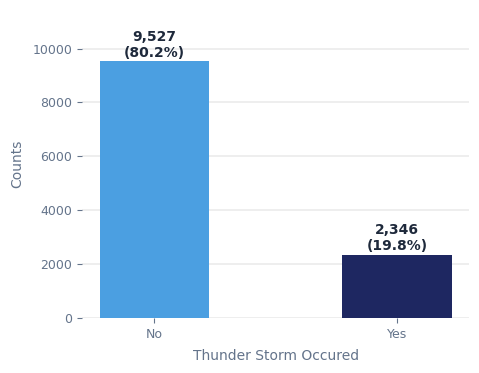

In [142]:
# dist of target variable
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["TH"].value_counts()
colors = [ACCENT, NAVY]
bars = ax.bar(counts.index, counts.values, color=colors, width=0.45, zorder=3, edgecolor="none")

for bar, val in zip(bars, counts.values):
    pct = val / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 60, f"{val:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10, fontweight="bold", color=DARK_TEXT)

ax.set_facecolor(WHITE)
ax.figure.patch.set_facecolor(WHITE)
ax.set_xlabel("Thunder Storm Occured", fontsize=10, color=MID_GRAY, labelpad=6)
ax.set_ylabel("Counts", fontsize=10, color=MID_GRAY, labelpad=6)
ax.set_xticks([0, 1])
ax.set_xticklabels(["No", "Yes"])

ax.tick_params(colors=MID_GRAY, labelsize=9)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linewidth=0.3)
ax.set_ylim(0, counts.max() * 1.2)

plt.savefig("../reports/charts/01_dist_target_variable.png", dpi=300, bbox_inches="tight", facecolor=WHITE);
# imbalanced data

##  Univariate Analysis

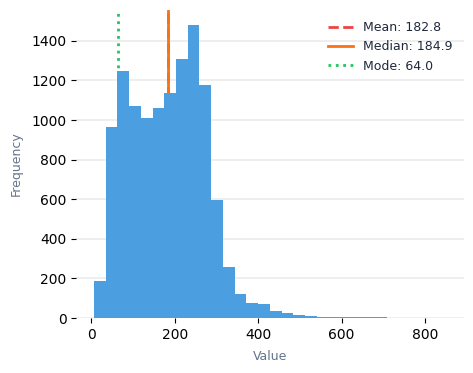

In [143]:
# SWEAT Index = Severe Weather Threat Index
fig, ax = plt.subplots(figsize=(5, 4))

ax.hist(df['SWEAT index'], bins=30, color=ACCENT, edgecolor="none", zorder=3)
ax.axvline(df['SWEAT index'].mean(), color=RED, linewidth=2, linestyle="--", label=f"Mean: {df['SWEAT index'].mean():.1f}")
ax.axvline(df['SWEAT index'].median(), color=ORANGE, linewidth=2, linestyle="-", label=f"Median: {df['SWEAT index'].median():.1f}")
ax.axvline(df['SWEAT index'].mode()[0], color=GREEN, linewidth=2, linestyle=":", label=f"Mode: {df['SWEAT index'].mode()[0]:.1f}")
ax.legend(frameon=False, fontsize=9, labelcolor=DARK_TEXT)
ax.set_xlabel("Value", fontsize=9, color=MID_GRAY, labelpad=6)
ax.set_ylabel("Frequency", fontsize=9, color=MID_GRAY, labelpad=6)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.yaxis.grid(True, linewidth=0.3)

plt.savefig("../reports/charts/02_sweat_index_histograms.png", dpi=300, bbox_inches="tight", facecolor=WHITE);

# 1. It is right skewed with the wide spread (high variance)
# 2. High SWEAT values (500+) are rare outliers, may represent extreme storm events
# 3. Action to take -> log/sqrt tranformation (To change the shape of the data) and StandardScalar (To change the scale of the data)

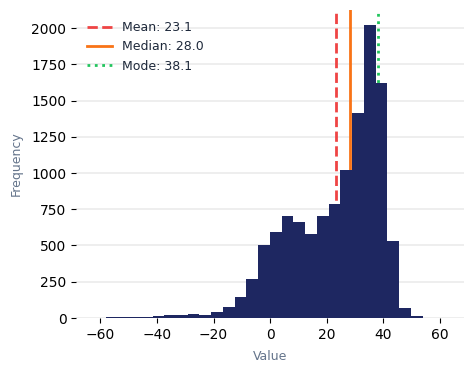

In [144]:
# K Index
fig, ax = plt.subplots(figsize=(5, 4))

ax.hist(df['K index'], bins=30, color=NAVY, edgecolor="none", zorder=3)
ax.axvline(df['K index'].mean(), color=RED, linewidth=2, linestyle="--", label=f"Mean: {df['K index'].mean():.1f}")
ax.axvline(df['K index'].median(), color=ORANGE, linewidth=2, linestyle="-", label=f"Median: {df['K index'].median():.1f}")
ax.axvline(df['K index'].mode()[0], color=GREEN, linewidth=2, linestyle=":", label=f"Mode: {df['K index'].mode()[0]:.1f}")
ax.legend(frameon=False, fontsize=9, labelcolor=DARK_TEXT)
ax.set_xlabel("Value", fontsize=9, color=MID_GRAY, labelpad=6)
ax.set_ylabel("Frequency", fontsize=9, color=MID_GRAY, labelpad=6)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.yaxis.grid(True, linewidth=0.3)

plt.savefig("../reports/charts/03_k_index_histograms.png", dpi=300, bbox_inches="tight", facecolor=WHITE);

# 1. It is left skewed. 
# 2. Negative K index values (-60 to 0) are rare, represent very dry, stable atmospheric conditions
# 3. Action to take -> Reflection + Log transformation (To change the shape of the data)

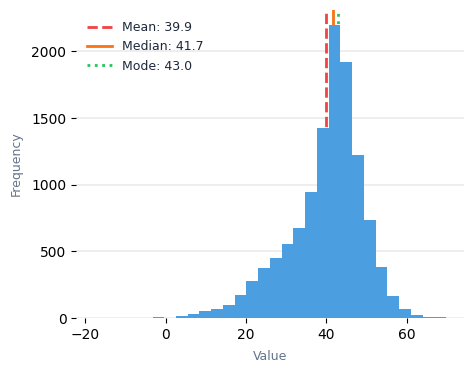

In [145]:
# Totals index
fig, ax = plt.subplots(figsize=(5, 4))

ax.hist(df['Totals index'], bins=30, color=ACCENT, edgecolor="none", zorder=3)
ax.axvline(df['Totals index'].mean(), color=RED, linewidth=2, linestyle="--", label=f"Mean: {df['Totals index'].mean():.1f}")
ax.axvline(df['Totals index'].median(), color=ORANGE, linewidth=2, linestyle="-", label=f"Median: {df['Totals index'].median():.1f}")
ax.axvline(df['Totals index'].mode()[0], color=GREEN, linewidth=2, linestyle=":", label=f"Mode: {df['Totals index'].mode()[0]:.1f}")
ax.legend(frameon=False, fontsize=9, labelcolor=DARK_TEXT)
ax.set_xlabel("Value", fontsize=9, color=MID_GRAY, labelpad=6)
ax.set_ylabel("Frequency", fontsize=9, color=MID_GRAY, labelpad=6)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.yaxis.grid(True, linewidth=0.3)

plt.savefig("../reports/charts/04_totals_index_histograms.png", dpi=300, bbox_inches="tight", facecolor=WHITE);

# 1. It is slight left skew
# 2. Tight distribution (−20 to 60), most days have similar storm total values, low variability compared to SWEAT index
# 3. Action to take -> No Tranformation Needed from my pov

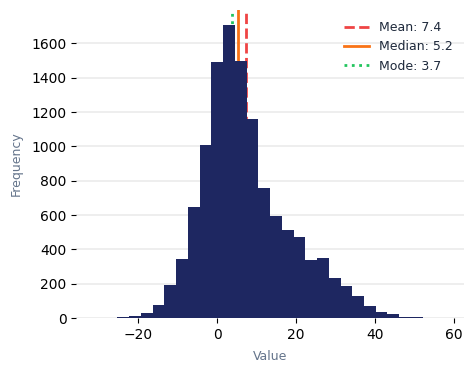

In [146]:
# Environmental Stability
fig, ax = plt.subplots(figsize=(5, 4))

ax.hist(df['Environmental Stability'], bins=30, color=NAVY, edgecolor="none", zorder=3)
ax.axvline(df['Environmental Stability'].mean(), color=RED, linewidth=2, linestyle="--", label=f"Mean: {df['Environmental Stability'].mean():.1f}")
ax.axvline(df['Environmental Stability'].median(), color=ORANGE, linewidth=2, linestyle="-", label=f"Median: {df['Environmental Stability'].median():.1f}")
ax.axvline(df['Environmental Stability'].mode()[0], color=GREEN, linewidth=2, linestyle=":", label=f"Mode: {df['Environmental Stability'].mode()[0]:.1f}")
ax.legend(frameon=False, fontsize=9, labelcolor=DARK_TEXT)
ax.set_xlabel("Value", fontsize=9, color=MID_GRAY, labelpad=6)
ax.set_ylabel("Frequency", fontsize=9, color=MID_GRAY, labelpad=6)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.yaxis.grid(True, linewidth=0.3)

plt.savefig("../reports/charts/05_environmental_stability_histograms.png", dpi=300, bbox_inches="tight", facecolor=WHITE);

# 1. It is right skewed (Mean > Median > Mode).
# 2. Negative values indicate highly stable atmospheric conditions
# 3. Action to take -> log/sqrt tranformation 

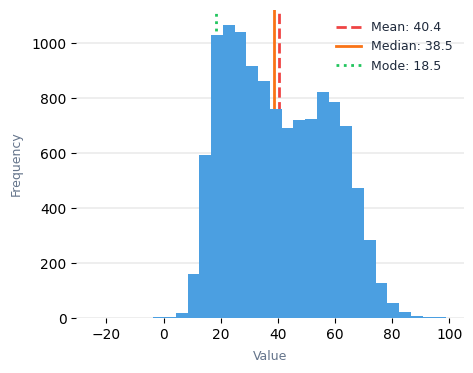

In [147]:
# Moisture Indices
fig, ax = plt.subplots(figsize=(5, 4))

ax.hist(df['Moisture Indices'], bins=30, color=ACCENT, edgecolor="none", zorder=3)
ax.axvline(df['Moisture Indices'].mean(), color=RED, linewidth=2, linestyle="--", label=f"Mean: {df['Moisture Indices'].mean():.1f}")
ax.axvline(df['Moisture Indices'].median(), color=ORANGE, linewidth=2, linestyle="-", label=f"Median: {df['Moisture Indices'].median():.1f}")
ax.axvline(df['Moisture Indices'].mode()[0], color=GREEN, linewidth=2, linestyle=":", label=f"Mode: {df['Moisture Indices'].mode()[0]:.1f}")
ax.legend(frameon=False, fontsize=9, labelcolor=DARK_TEXT)
ax.set_xlabel("Value", fontsize=9, color=MID_GRAY, labelpad=6)
ax.set_ylabel("Frequency", fontsize=9, color=MID_GRAY, labelpad=6)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.yaxis.grid(True, linewidth=0.3)

plt.savefig("../reports/charts/06_moisture_indices_histograms.png", dpi=300, bbox_inches="tight", facecolor=WHITE);

# 1. It is bimodal (Two clear peaks) + right skewed distribution. 
# 2. Bimodal distribution tells feature may be a strong separator between storm and non-storm days
# 3. Action to take -> log tranformation 

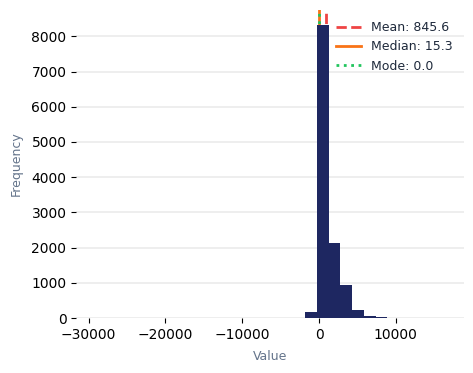

In [148]:
# Convective Potential
fig, ax = plt.subplots(figsize=(5, 4))

ax.hist(df['Convective Potential'], bins=30, color=NAVY, edgecolor="none", zorder=3)
ax.axvline(df['Convective Potential'].mean(), color=RED, linewidth=2, linestyle="--", label=f"Mean: {df['Convective Potential'].mean():.1f}")
ax.axvline(df['Convective Potential'].median(), color=ORANGE, linewidth=2, linestyle="-", label=f"Median: {df['Convective Potential'].median():.1f}")
ax.axvline(df['Convective Potential'].mode()[0], color=GREEN, linewidth=2, linestyle=":", label=f"Mode: {df['Convective Potential'].mode()[0]:.1f}")
ax.legend(frameon=False, fontsize=9, labelcolor=DARK_TEXT)
ax.set_xlabel("Value", fontsize=9, color=MID_GRAY, labelpad=6)
ax.set_ylabel("Frequency", fontsize=9, color=MID_GRAY, labelpad=6)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.yaxis.grid(True, linewidth=0.3)

plt.savefig("../reports/charts/07_convective_potential_histograms.png", dpi=300, bbox_inches="tight", facecolor=WHITE);

# 1. extremely right skewed + heavy outliers
# 2. Extreme negative values (−30,000) are likely data errors or very rare anomalous events
# 3. Action to take -> requires outlier removal + log/power tranformation

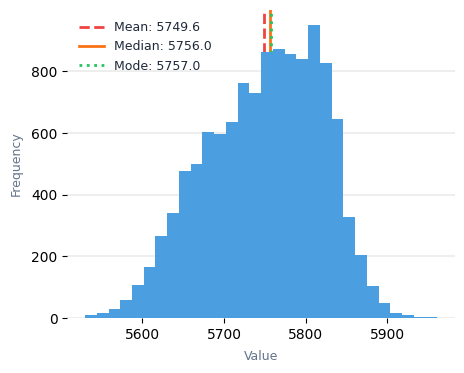

In [149]:
# Temperature Pressure
fig, ax = plt.subplots(figsize=(5, 4))

ax.hist(df['Temperature Pressure'], bins=30, color=ACCENT, edgecolor="none", zorder=3)
ax.axvline(df['Temperature Pressure'].mean(), color=RED, linewidth=2, linestyle="--", label=f"Mean: {df['Temperature Pressure'].mean():.1f}")
ax.axvline(df['Temperature Pressure'].median(), color=ORANGE, linewidth=2, linestyle="-", label=f"Median: {df['Temperature Pressure'].median():.1f}")
ax.axvline(df['Temperature Pressure'].mode()[0], color=GREEN, linewidth=2, linestyle=":", label=f"Mode: {df['Temperature Pressure'].mode()[0]:.1f}")
ax.legend(frameon=False, fontsize=9, labelcolor=DARK_TEXT)
ax.set_xlabel("Value", fontsize=9, color=MID_GRAY, labelpad=6)
ax.set_ylabel("Frequency", fontsize=9, color=MID_GRAY, labelpad=6)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.yaxis.grid(True, linewidth=0.3)

plt.savefig("../reports/charts/08_temperature_pressure_histograms.png", dpi=300, bbox_inches="tight", facecolor=WHITE);

# 1. Nearly normal distributed
# 2. It has very narrow range (low variance)
# 3. Action to take -> No Tranformation Needed from my pov

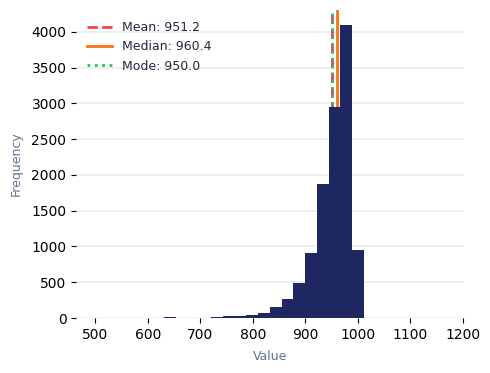

In [150]:
# Moisture Temperature Profiles
fig, ax = plt.subplots(figsize=(5, 4))

ax.hist(df['Moisture Temperature Profiles'], bins=30, color=NAVY, edgecolor="none", zorder=3)
ax.axvline(df['Moisture Temperature Profiles'].mean(), color=RED, linewidth=2, linestyle="--", label=f"Mean: {df['Moisture Temperature Profiles'].mean():.1f}")
ax.axvline(df['Moisture Temperature Profiles'].median(), color=ORANGE, linewidth=2, linestyle="-", label=f"Median: {df['Moisture Temperature Profiles'].median():.1f}")
ax.axvline(df['Moisture Temperature Profiles'].mode()[0], color=GREEN, linewidth=2, linestyle=":", label=f"Mode: {df['Moisture Temperature Profiles'].mode()[0]:.1f}")
ax.legend(frameon=False, fontsize=9, labelcolor=DARK_TEXT)
ax.set_xlabel("Value", fontsize=9, color=MID_GRAY, labelpad=6)
ax.set_ylabel("Frequency", fontsize=9, color=MID_GRAY, labelpad=6)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.yaxis.grid(True, linewidth=0.3)

plt.savefig("../reports/charts/09_moisture_temperature_profiles_histograms.png", dpi=300, bbox_inches="tight", facecolor=WHITE);

# 1. It is left skewed 
# 2. Extremely tight clustering around 900–1000, very low day-to-day variability in this feature
# 3. Action to take -> reflection + log transformation

##  Bivariate Analysis

- Categorical vs Categorical - Bar chart / Stacked bar - Chi-Square Test, Cramer's V Test
- Categorical vs Numerical - Boxplot / Violin plot - T-Test, Point Biserial (binary category only), ANOVA (cat > 2)
- Numerical vs Numerical - Scatter plot - Correlation, Pearson's R (linear), pearman correlation (for non-linear)

In [151]:
# point biserial ranks features, t-test confirms them
results = []
for col in df.columns.drop(["Date", "TH"]):
    corr, pval = pointbiserialr(df[col], df['TH'])
    g0 = df[df['TH']==0][col]
    g1 = df[df['TH']==1][col]
    t_stat, t_pval = ttest_ind(g0, g1)
    results.append({
        'Feature': col, 
        'Correlation': round(corr, 3), 
        'P-Value': round(pval, 4),
        'Mean (TH=0)':  round(g0.mean(), 2),
        'Mean (TH=1)': round(g1.mean(), 2),
        'T-Statistic': round(t_stat, 3),
        'T P-Value': round(t_pval, 4),
        'Significant': 'Yes' if t_pval < 0.05 else 'No'
        })

corr_df = pd.DataFrame(results).sort_values('Correlation', key=abs, ascending=False)
corr_df

,Feature,Correlation,P-Value,Mean (TH=0),Mean (TH=1),T-Statistic,T P-Value,Significant
4,Moisture Indices,0.354,0.0,37.36,52.92,-41.219,0.0,Yes
1,K index,0.326,0.0,20.53,33.55,-37.532,0.0,Yes
0,SWEAT index,0.287,0.0,169.69,236.24,-32.704,0.0,Yes
6,Temperature Pressure,0.274,0.0,5740.01,5788.34,-31.047,0.0,Yes
2,Totals index,0.257,0.0,38.73,44.75,-28.995,0.0,Yes
3,Environmental Stability,-0.253,0.0,8.81,1.69,28.521,0.0,Yes
5,Convective Potential,0.177,0.0,720.23,1354.82,-19.564,0.0,Yes
7,Moisture Temperature Profiles,0.086,0.0,949.47,958.15,-9.358,0.0,Yes


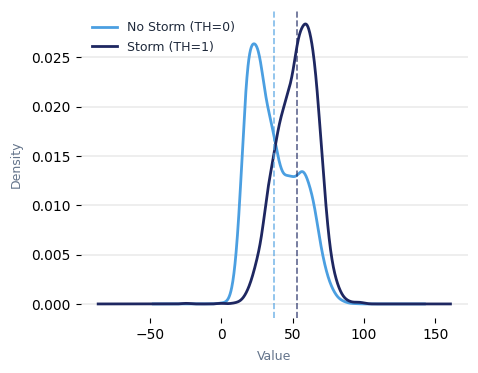

In [152]:
# Moisture Indices distribution by TH class
fig, ax = plt.subplots(figsize=(5, 4))

df[df['TH'] == 0]['Moisture Indices'].plot(kind='kde', ax=ax, color=ACCENT, linewidth=2, label='No Storm (TH=0)')
df[df['TH'] == 1]['Moisture Indices'].plot(kind='kde', ax=ax, color=NAVY, linewidth=2, label='Storm (TH=1)')

ax.axvline(df[df['TH']==0]['Moisture Indices'].mean(), color=ACCENT, linewidth=1.2, linestyle='--', alpha=0.7)
ax.axvline(df[df['TH']==1]['Moisture Indices'].mean(), color=NAVY, linewidth=1.2, linestyle='--', alpha=0.7)
ax.set_xlabel('Value', fontsize=9, color=MID_GRAY, labelpad=6)
ax.set_ylabel('Density', fontsize=9, color=MID_GRAY, labelpad=6)
ax.legend(frameon=False, fontsize=9, labelcolor=DARK_TEXT)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.yaxis.grid(True, linewidth=0.3)

plt.savefig('../reports/charts/10_moisture_indices_kde.png', dpi=300, bbox_inches='tight', facecolor=WHITE);

# Means are visibly separated + each curve have large area outside the overlap zone + peaks don't sit on each other = Good separartion = confirmed as the strong predictor

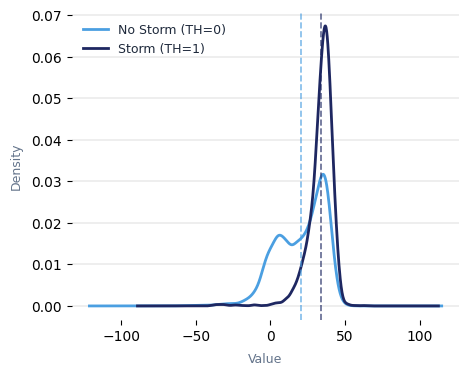

In [153]:
# K index distribution by TH class
fig, ax = plt.subplots(figsize=(5, 4))

df[df['TH'] == 0]['K index'].plot(kind='kde', ax=ax, color=ACCENT, linewidth=2, label='No Storm (TH=0)')
df[df['TH'] == 1]['K index'].plot(kind='kde', ax=ax, color=NAVY, linewidth=2, label='Storm (TH=1)')

ax.axvline(df[df['TH']==0]['K index'].mean(), color=ACCENT, linewidth=1.2, linestyle='--', alpha=0.7)
ax.axvline(df[df['TH']==1]['K index'].mean(), color=NAVY, linewidth=1.2, linestyle='--', alpha=0.7)
ax.set_xlabel('Value', fontsize=9, color=MID_GRAY, labelpad=6)
ax.set_ylabel('Density', fontsize=9, color=MID_GRAY, labelpad=6)
ax.legend(frameon=False, fontsize=9, labelcolor=DARK_TEXT)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.yaxis.grid(True, linewidth=0.3)

plt.savefig('../reports/charts/11_k_index_kde.png', dpi=300, bbox_inches='tight', facecolor=WHITE);

# Means are visibly separated + Large overlap area (it alone cannot fully separate classes) = Good predictor

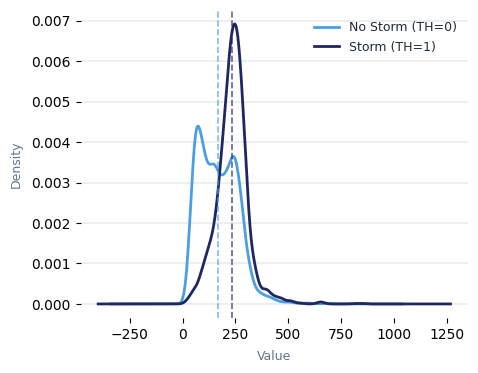

In [154]:
# SWEAT index distribution by TH class
fig, ax = plt.subplots(figsize=(5, 4))

df[df['TH'] == 0]['SWEAT index'].plot(kind='kde', ax=ax, color=ACCENT, linewidth=2, label='No Storm (TH=0)')
df[df['TH'] == 1]['SWEAT index'].plot(kind='kde', ax=ax, color=NAVY, linewidth=2, label='Storm (TH=1)')

ax.axvline(df[df['TH']==0]['SWEAT index'].mean(), color=ACCENT, linewidth=1.2, linestyle='--', alpha=0.7)
ax.axvline(df[df['TH']==1]['SWEAT index'].mean(), color=NAVY, linewidth=1.2, linestyle='--', alpha=0.7)
ax.set_xlabel('Value', fontsize=9, color=MID_GRAY, labelpad=6)
ax.set_ylabel('Density', fontsize=9, color=MID_GRAY, labelpad=6)
ax.legend(frameon=False, fontsize=9, labelcolor=DARK_TEXT)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.yaxis.grid(True, linewidth=0.3)

plt.savefig('../reports/charts/12_sweat_index_kde.png', dpi=300, bbox_inches='tight', facecolor=WHITE);

# Means are visibly separated + Heavy overlap area (it alone cannot fully separate classes) + bimodal = Moderate predictor

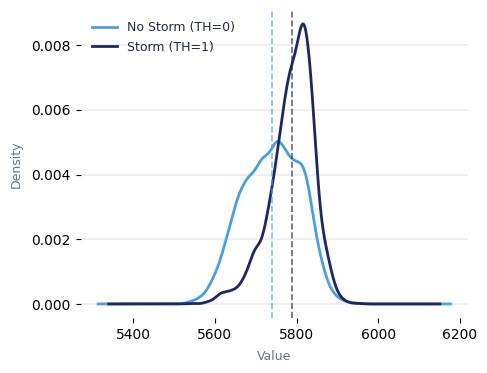

In [155]:
# Temperature Pressure distribution by TH class
fig, ax = plt.subplots(figsize=(5, 4))

df[df['TH'] == 0]['Temperature Pressure'].plot(kind='kde', ax=ax, color=ACCENT, linewidth=2, label='No Storm (TH=0)')
df[df['TH'] == 1]['Temperature Pressure'].plot(kind='kde', ax=ax, color=NAVY, linewidth=2, label='Storm (TH=1)')

ax.axvline(df[df['TH']==0]['Temperature Pressure'].mean(), color=ACCENT, linewidth=1.2, linestyle='--', alpha=0.7)
ax.axvline(df[df['TH']==1]['Temperature Pressure'].mean(), color=NAVY, linewidth=1.2, linestyle='--', alpha=0.7)
ax.set_xlabel('Value', fontsize=9, color=MID_GRAY, labelpad=6)
ax.set_ylabel('Density', fontsize=9, color=MID_GRAY, labelpad=6)
ax.legend(frameon=False, fontsize=9, labelcolor=DARK_TEXT)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.yaxis.grid(True, linewidth=0.3)

plt.savefig('../reports/charts/13_temperature_pressure_kde.png', dpi=300, bbox_inches='tight', facecolor=WHITE);

# Means are visibly separated + Large overlap area (it alone cannot fully separate classes) = Moderate predictor

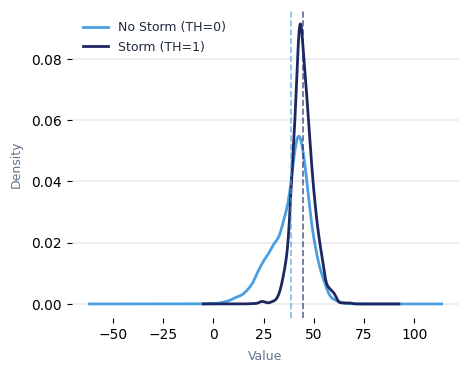

In [156]:
# Totals index distribution by TH class
fig, ax = plt.subplots(figsize=(5, 4))

df[df['TH'] == 0]['Totals index'].plot(kind='kde', ax=ax, color=ACCENT, linewidth=2, label='No Storm (TH=0)')
df[df['TH'] == 1]['Totals index'].plot(kind='kde', ax=ax, color=NAVY, linewidth=2, label='Storm (TH=1)')

ax.axvline(df[df['TH']==0]['Totals index'].mean(), color=ACCENT, linewidth=1.2, linestyle='--', alpha=0.7)
ax.axvline(df[df['TH']==1]['Totals index'].mean(), color=NAVY, linewidth=1.2, linestyle='--', alpha=0.7)
ax.set_xlabel('Value', fontsize=9, color=MID_GRAY, labelpad=6)
ax.set_ylabel('Density', fontsize=9, color=MID_GRAY, labelpad=6)
ax.legend(frameon=False, fontsize=9, labelcolor=DARK_TEXT)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.yaxis.grid(True, linewidth=0.3)

plt.savefig('../reports/charts/14_totals_index_kde.png', dpi=300, bbox_inches='tight', facecolor=WHITE);

# Means are visibly separated + Very large overlap area = weak predictor

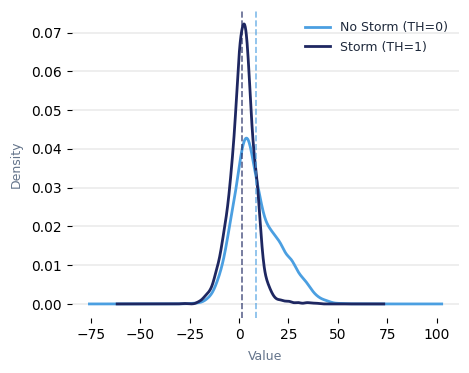

In [157]:
# Environmental Stability distribution by TH class
fig, ax = plt.subplots(figsize=(5, 4))

df[df['TH'] == 0]['Environmental Stability'].plot(kind='kde', ax=ax, color=ACCENT, linewidth=2, label='No Storm (TH=0)')
df[df['TH'] == 1]['Environmental Stability'].plot(kind='kde', ax=ax, color=NAVY, linewidth=2, label='Storm (TH=1)')

ax.axvline(df[df['TH']==0]['Environmental Stability'].mean(), color=ACCENT, linewidth=1.2, linestyle='--', alpha=0.7)
ax.axvline(df[df['TH']==1]['Environmental Stability'].mean(), color=NAVY, linewidth=1.2, linestyle='--', alpha=0.7)
ax.set_xlabel('Value', fontsize=9, color=MID_GRAY, labelpad=6)
ax.set_ylabel('Density', fontsize=9, color=MID_GRAY, labelpad=6)
ax.legend(frameon=False, fontsize=9, labelcolor=DARK_TEXT)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.yaxis.grid(True, linewidth=0.3)

plt.savefig('../reports/charts/15_environmental_stability_kde.png', dpi=300, bbox_inches='tight', facecolor=WHITE);

# Means are visibly separated + Very large overlap area = weakest predictor

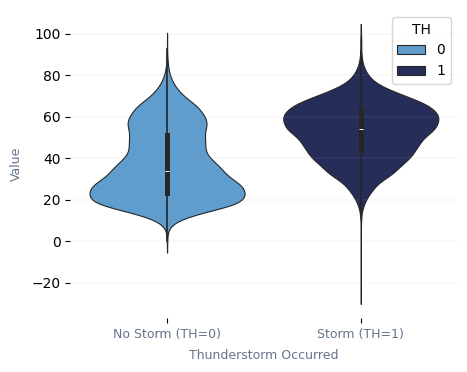

In [ ]:
# violin + box plot for Moisture Indices by TH class
fig, ax = plt.subplots(figsize=(5, 4))

sns.violinplot(x='TH', y='Moisture Indices', data=df, hue='TH', palette=[ACCENT, NAVY], inner='box', linewidth=0.8, ax=ax)

ax.set_xlabel('Thunderstorm Occurred', fontsize=9, color=MID_GRAY, labelpad=6)
ax.set_ylabel('Value', fontsize=9, color=MID_GRAY, labelpad=6)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Storm (TH=0)', 'Storm (TH=1)'], fontsize=9, color=MID_GRAY)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.yaxis.grid(True, linewidth=0.1)

plt.savefig('../reports/charts/16_moisture_indices_boxplots.png', dpi=300, bbox_inches='tight', facecolor=WHITE);

# white dot = median position (visble difference)
# different shapes = strong predictor
# small overlap on black box/iqr box

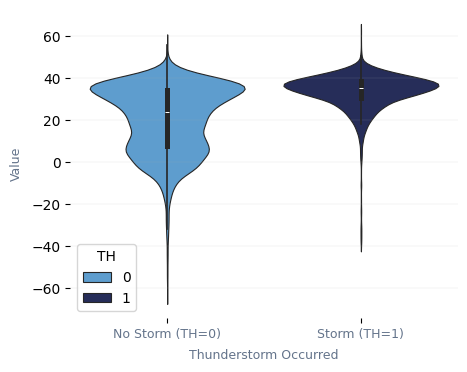

In [159]:
# violin + box plot for K index by TH class
fig, ax = plt.subplots(figsize=(5, 4))

sns.violinplot(x='TH', y='K index', data=df, hue='TH', palette=[ACCENT, NAVY], inner='box', linewidth=0.8, ax=ax)

ax.set_xlabel('Thunderstorm Occurred', fontsize=9, color=MID_GRAY, labelpad=6)
ax.set_ylabel('Value', fontsize=9, color=MID_GRAY, labelpad=6)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Storm (TH=0)', 'Storm (TH=1)'], fontsize=9, color=MID_GRAY)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.yaxis.grid(True, linewidth=0.1)

plt.savefig('../reports/charts/17_k_index_boxplots.png', dpi=300, bbox_inches='tight', facecolor=WHITE);

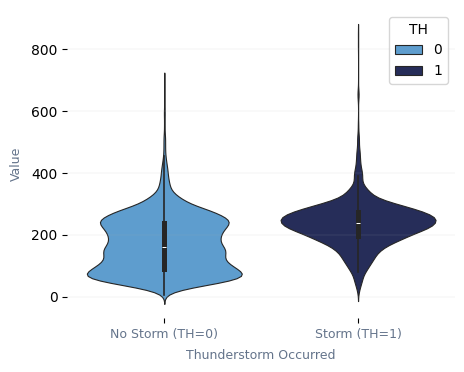

In [160]:
# violin + box plot for SWEAT index by TH class
fig, ax = plt.subplots(figsize=(5, 4))

sns.violinplot(x='TH', y='SWEAT index', data=df, hue='TH', palette=[ACCENT, NAVY], inner='box', linewidth=0.8, ax=ax)

ax.set_xlabel('Thunderstorm Occurred', fontsize=9, color=MID_GRAY, labelpad=6)
ax.set_ylabel('Value', fontsize=9, color=MID_GRAY, labelpad=6)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Storm (TH=0)', 'Storm (TH=1)'], fontsize=9, color=MID_GRAY)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.yaxis.grid(True, linewidth=0.1)

plt.savefig('../reports/charts/18_sweat_index_boxplots.png', dpi=300, bbox_inches='tight', facecolor=WHITE);

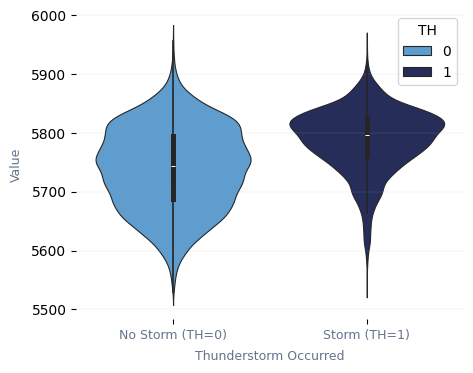

In [161]:
# violin + box plot for Temperature Pressure by TH class
fig, ax = plt.subplots(figsize=(5, 4))

sns.violinplot(x='TH', y='Temperature Pressure', data=df, hue='TH', palette=[ACCENT, NAVY], inner='box', linewidth=0.8, ax=ax)

ax.set_xlabel('Thunderstorm Occurred', fontsize=9, color=MID_GRAY, labelpad=6)
ax.set_ylabel('Value', fontsize=9, color=MID_GRAY, labelpad=6)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Storm (TH=0)', 'Storm (TH=1)'], fontsize=9, color=MID_GRAY)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.yaxis.grid(True, linewidth=0.1)

plt.savefig('../reports/charts/19_temperature_pressure_boxplots.png', dpi=300, bbox_inches='tight', facecolor=WHITE);

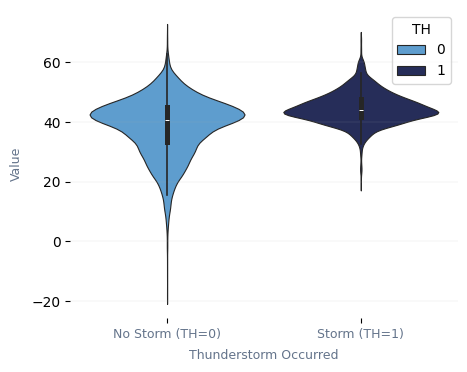

In [162]:
# violin + box plot for Totals index by TH class
fig, ax = plt.subplots(figsize=(5, 4))

sns.violinplot(x='TH', y='Totals index', data=df, hue='TH', palette=[ACCENT, NAVY], inner='box', linewidth=0.8, ax=ax)

ax.set_xlabel('Thunderstorm Occurred', fontsize=9, color=MID_GRAY, labelpad=6)
ax.set_ylabel('Value', fontsize=9, color=MID_GRAY, labelpad=6)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Storm (TH=0)', 'Storm (TH=1)'], fontsize=9, color=MID_GRAY)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.yaxis.grid(True, linewidth=0.1)

plt.savefig('../reports/charts/20_totals_index_boxplots.png', dpi=300, bbox_inches='tight', facecolor=WHITE);

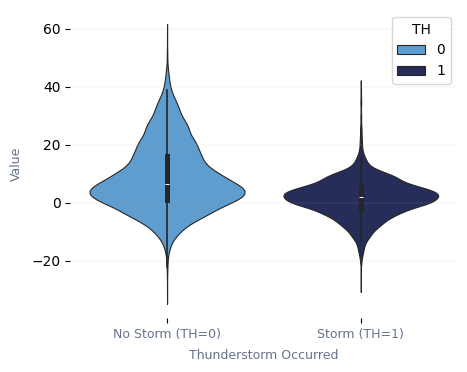

In [163]:
# violin + box plot for Environmental Stability by TH class
fig, ax = plt.subplots(figsize=(5, 4))

sns.violinplot(x='TH', y='Environmental Stability', data=df, hue='TH', palette=[ACCENT, NAVY], inner='box', linewidth=0.8, ax=ax)

ax.set_xlabel('Thunderstorm Occurred', fontsize=9, color=MID_GRAY, labelpad=6)
ax.set_ylabel('Value', fontsize=9, color=MID_GRAY, labelpad=6)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Storm (TH=0)', 'Storm (TH=1)'], fontsize=9, color=MID_GRAY)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.yaxis.grid(True, linewidth=0.1)

plt.savefig('../reports/charts/21_environmental_stability_boxplots.png', dpi=300, bbox_inches='tight', facecolor=WHITE);

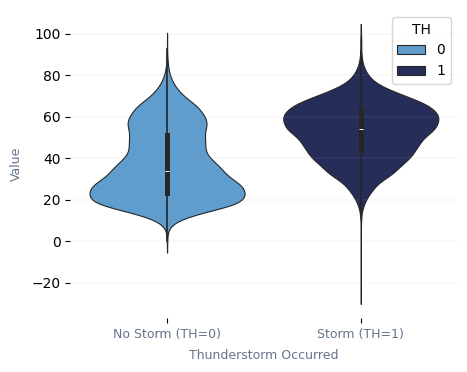

In [164]:
# violin + box plot for Moisture Indices by TH class
fig, ax = plt.subplots(figsize=(5, 4))

sns.violinplot(x='TH', y='Moisture Indices', data=df, hue='TH', palette=[ACCENT, NAVY], inner='box', linewidth=0.8, ax=ax)

ax.set_xlabel('Thunderstorm Occurred', fontsize=9, color=MID_GRAY, labelpad=6)
ax.set_ylabel('Value', fontsize=9, color=MID_GRAY, labelpad=6)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Storm (TH=0)', 'Storm (TH=1)'], fontsize=9, color=MID_GRAY)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.yaxis.grid(True, linewidth=0.1)

plt.savefig('../reports/charts/22_moisture_indices_boxplots.png', dpi=300, bbox_inches='tight', facecolor=WHITE);

## Multivariate Analysis

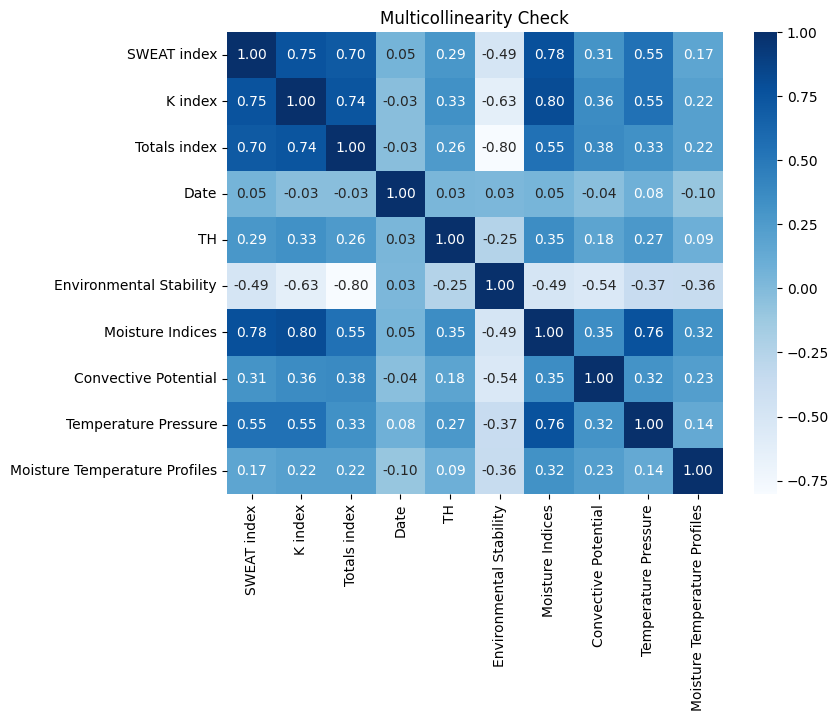

In [ ]:
# Multicollinearity
selected = df.columns

plt.figure(figsize=(8, 6))
sns.heatmap(df[selected].corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Multicollinearity Check')
plt.savefig('../reports/charts/23_multicollinearity_check_heatmap.png', dpi=300, bbox_inches='tight', facecolor=WHITE);

#  Flag - flag = K Index vs Moisture Indices = 0.80, Totals Index vs Env Stability = -0.80